In [1]:
# Importing the python libraries
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier


In [1]:
Modelling_Data = pd.read_csv('../FinLora_Dataset/artifacts/Engineered_Data.csv')

NameError: name 'pd' is not defined

In [14]:
Modelling_Data.head()


,Unnamed: 0,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,...,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud,home_country_norm,ip_country_norm,kyc_tier_norm,country_mismatch
0,0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,atm,278.19,278.19,...,0,0.223,0,0,0.0,0,United States,United States,Tier 2,False
1,1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,...,0,0.268,0,1,0.0,0,Canada,Canada,Tier 2,False
2,2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,...,0,0.176,0,0,0.0,0,United States,United States,Tier 3,False
3,3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,...,0,0.391,0,0,0.0,0,United States,United States,Tier 2,False
4,4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,...,0,0.257,0,0,0.0,0,United States,United States,Tier 3,False


In [30]:
Modelling_Data['timestamp'] = pd.to_datetime(Modelling_Data['timestamp'])

In [33]:
Modelling_Data.columns


Index(['Unnamed: 0', 'transaction_id', 'customer_id', 'timestamp',
       'home_country', 'source_currency', 'dest_currency', 'channel',
       'amount_src', 'amount_usd', 'fee', 'exchange_rate_src_to_dest',
       'device_id', 'new_device', 'ip_address', 'ip_country',
       'location_mismatch', 'ip_risk_score', 'kyc_tier', 'account_age_days',
       'device_trust_score', 'chargeback_history_count', 'risk_score_internal',
       'txn_velocity_1h', 'txn_velocity_24h', 'corridor_risk', 'is_fraud',
       'home_country_norm', 'ip_country_norm', 'kyc_tier_norm',
       'country_mismatch'],
      dtype='object')

In [28]:
# Defining numerical features
numerical_features = Modelling_Data.select_dtypes(include=['int', 'float']).columns.drop('is_fraud')
numerical_features

Index(['Unnamed: 0', 'amount_src', 'amount_usd', 'fee',
       'exchange_rate_src_to_dest', 'ip_risk_score', 'account_age_days',
       'device_trust_score', 'chargeback_history_count', 'risk_score_internal',
       'txn_velocity_1h', 'txn_velocity_24h', 'corridor_risk'],
      dtype='object')

In [4]:
import pandas as pd

# 1. Load the dataset using the relative path from the Notebooks directory
Modelling_Data = pd.read_csv('../FinLora_Dataset/artifacts/Engineered_Data.csv')
Modelling_Data['timestamp'] = pd.to_datetime(Modelling_Data['timestamp'])

# 2. Define non-predictive columns and extract feature lists
drop_cols = ['Unnamed: 0', 'transaction_id', 'customer_id', 'timestamp', 'device_id', 'ip_address', 'is_fraud']

categorical_features = Modelling_Data.drop(columns=[c for c in drop_cols if c in Modelling_Data.columns]) \
                                     .select_dtypes(include=['object', 'bool']).columns.tolist()

numerical_features = Modelling_Data.drop(columns=[c for c in drop_cols if c in Modelling_Data.columns]) \
                                   .select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()

all_features = categorical_features + numerical_features

# 3. Chronological sort and 80/20 train-test split
Modelling_Data = Modelling_Data.sort_values(by='timestamp')

split_index = int(len(Modelling_Data) * 0.8)
train_Modelling_Data = Modelling_Data.iloc[:split_index]
test_Modelling_Data = Modelling_Data.iloc[split_index:]

# 4. Prepare X and y matrices
X_train = train_Modelling_Data[all_features]
y_train = train_Modelling_Data['is_fraud']
X_test = test_Modelling_Data[all_features]
y_test = test_Modelling_Data['is_fraud']

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

X_train: (8672, 24), y_train: (8672,)
X_test: (2168, 24), y_test: (2168,)


In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay

# Building preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features)
    ]
)

# Fit on train, transform both
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Original features: {len(all_features)}")
print(f"Processed features: {X_train_processed.shape[1]}")

Original features: 24
Processed features: 63


## Training Logistic Regression with Balanced Class Weight

This section trains a Logistic Regression model while handling class imbalance using `class_weight='balanced'`.

In [7]:
# Create Logistic Regression model
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)


In [11]:
# Build the complete pipeline
pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', lr_model)
    ]
)

In [14]:
# Train the pipeline
pipeline.fit(X_train, y_train)

# Make predictions
y_pred_lr = pipeline.predict(X_test)
y_proba_lr = pipeline.predict_proba(X_test)[:, 1]

# Evaluation
print("Logistic Regression Results:")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Genuine', 'Fraud']))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

print(f"\nROC_AUC Score: {roc_auc_score(y_test, y_proba_lr):.4f}")


Logistic Regression Results:

Classification Report:
              precision    recall  f1-score   support

     Genuine       0.99      0.96      0.98      1860
       Fraud       0.80      0.94      0.87       308

    accuracy                           0.96      2168
   macro avg       0.90      0.95      0.92      2168
weighted avg       0.96      0.96      0.96      2168


Confusion Matrix:
[[1789   71]
 [  18  290]]

ROC_AUC Score: 0.9809


<Figure size 800x600 with 0 Axes>

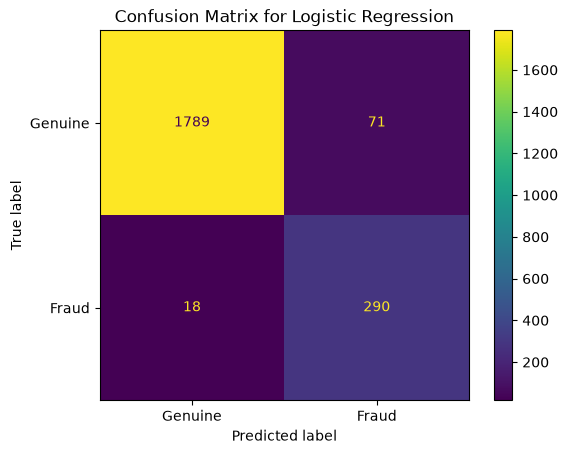

In [18]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion Matrix for Logistic Regression
cm = ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_lr),
    display_labels=['Genuine', 'Fraud']
)

plt.figure(figsize=(8, 6))
cm.plot()
plt.title("Confusion Matrix for Logistic Regression")
plt.show()


In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# Create Random Forest model
rf_model = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_estimators=100,
    max_depth=10,
    n_jobs=-1
)

# Build the complete pipeline
pipeline_rf = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', rf_model)
    ]
)

# Train the pipeline (using raw X_train, not processed)
pipeline_rf.fit(X_train, y_train)

# Make predictions
y_pred_rf = pipeline_rf.predict(X_test)
y_proba_rf = pipeline_rf.predict_proba(X_test)[:, 1]

# Evaluation
print("Random Forest Results:")
print("Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Genuine', 'Fraud']))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("ROC AUC Score: {:.4f}".format(roc_auc_score(y_test, y_proba_rf)))


Random Forest Results:
Classification Report:
              precision    recall  f1-score   support

     Genuine       0.99      1.00      0.99      1860
       Fraud       0.97      0.92      0.95       308

    accuracy                           0.99      2168
   macro avg       0.98      0.96      0.97      2168
weighted avg       0.99      0.99      0.99      2168

Confusion Matrix:
[[1852    8]
 [  24  284]]
ROC AUC Score: 0.9771


<Figure size 800x600 with 0 Axes>

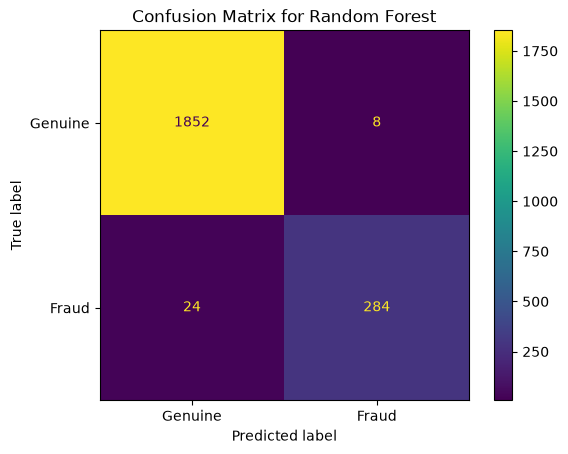

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion Matrix for Random Forest (second result)
cm = ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_rf),
    display_labels=['Genuine', 'Fraud']
)

plt.figure(figsize=(8, 6))
cm.plot()
plt.title("Confusion Matrix for Random Forest")
plt.show()
